In [1]:
import sys
module_path = '/Users/woodml/Code/XMM_SAS/xmmsas_20230412_1735/lib/python' # or the path to your source code
sys.path.insert(0, module_path)
%env SAS_PATH=/Users/woodml/Code/XMM_SAS/xmmsas_20230412_1735
from pysas.wrapper import Wrapper as w
import os
import os.path
from os import path
import numpy as np
from astropy.io import fits
from astropy.table import Table

from extraction_fcns import extract_lc, extract_spectrum, plot_LC, plot_region, plot_spectrum, rolling_median

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Georgia']
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.linewidth'] = 1

env: SAS_PATH=/Users/woodml/Code/XMM_SAS/xmmsas_20230412_1735


In [2]:
work_dir = '/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/'
sas_file = '/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/'

inargs = [f'sas_ccf={sas_file}ccf.cif', f'sas_odf={sas_file}0327_0101440801_SCX00000SUM.SAS', f'workdir={work_dir}']

w('startsas', inargs).run()

startsas - WARNING - Executing /Users/woodml/Code/XMM_SAS/xmmsas_20230412_1735/lib/python/pysas/startsas/startsas.py {'odfid': '', 'workdir': '/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/', 'sasfiles': 'yes', 'sas_ccf': '/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ccf.cif', 'sas_odf': '/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/0327_0101440801_SCX00000SUM.SAS', 'level': 'ODF', 'cifbuild_opts': '', 'odfingest_opts': ''}




        Starting SAS session
    
        Working directory = /Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/
    
        
SAS_CCF = /Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ccf.cif
SAS_ODF = /Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/0327_0101440801_SCX00000SUM.SAS


# LC's

In [3]:
# Get Time Limits
print('EMOS 1')
hdul = fits.open('0327_0101440801_EMOS1_S001_ImagingEvts.ds')
e1 = Table(hdul[1].data)
e1.sort('TIME')

print('  Time Start: ', e1['TIME'][0])
print('  Time End:   ', e1['TIME'][-1])

print('EMOS 1')
hdul = fits.open('0327_0101440801_EMOS2_S002_ImagingEvts.ds')
e2 = Table(hdul[1].data)
e2.sort('TIME')

print('  Time Start: ', e2['TIME'][0])
print('  Time End:   ', e2['TIME'][-1])

print('\n\nTime Interval: ', np.ceil(np.max([e1['TIME'][0], e2['TIME'][0]])), '-', np.floor(np.min([e1['TIME'][-1], e2['TIME'][-1]])))

EMOS 1
  Time Start:  117423317.8194496
  Time End:    117552866.50447723
EMOS 1
  Time Start:  117423317.92000268
  Time End:    117552923.54116663


Time Interval:  117423318.0 - 117552866.0


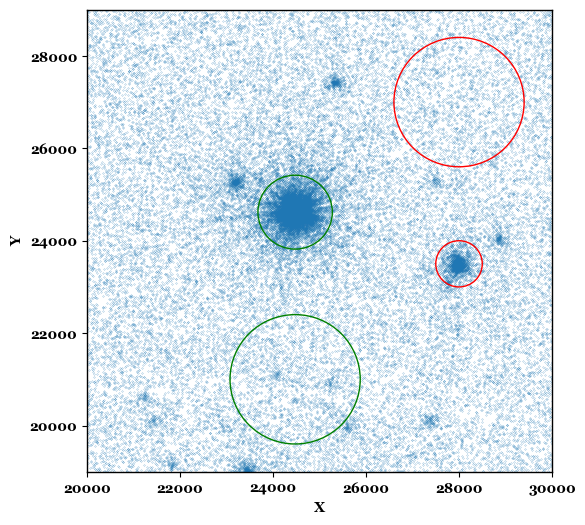

In [52]:
# Plot Image, Determine Extraction Region
event_file   = '0327_0101440801_EMOS1_S001_ImagingEvts.ds'

su_aur = (24475.391, 24618.401)
ab_aur = (28000, 23500)

hdul = fits.open(event_file)
events = Table(hdul[1].data)

_, ax = plt.subplots(figsize=(6, 6))
plt.scatter(events['X'], events['Y'], marker='.', s=0.1)
p = plt.Circle(su_aur, 800, edgecolor='green', fill=False)
ax.add_artist(p)
p = plt.Circle(ab_aur, 500, edgecolor='red', fill=False)
ax.add_artist(p)
p = plt.Circle((24475.391, 21000.5), 1400, edgecolor='green', fill=False)
ax.add_artist(p)
p = plt.Circle((28000, 27000.5), 1400, edgecolor='red', fill=False)
ax.add_artist(p)
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(20000, 30000)
plt.ylim(19000, 29000)
plt.show()

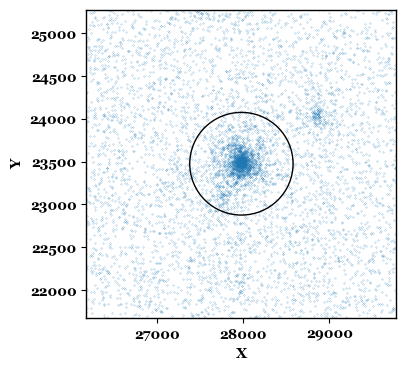



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/0327_0101440801_EMOS1_S001_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS1&&(PATTERN<=12)&&((X,Y) IN circle(27979.576,23475.568,600))&&(PI in [200.0:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='n

/Users/woodml/anaconda3/envs/Observing/lib/python3.10/site-packages/matplotlib/cbook.py:1345: RuntimeWarning: invalid value encountered in cast
  return np.asarray(x, float)


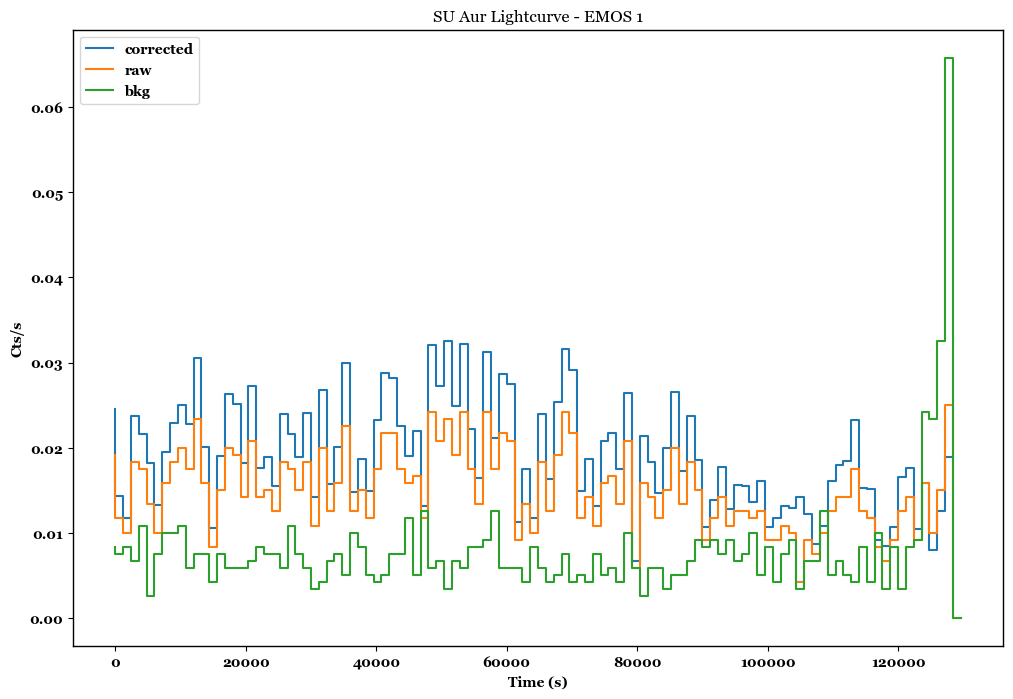

In [9]:
# EMOS 1 Extraction

# Prepare
region_1     = (27979.576, 23475.568)
radius       = 600
bkg_1        = (27979.576, 27000.5)
bkg_radius   = 1400

q_flag       = "#XMMEA_EMOS1" # Quality flag for EPIC MOS 1
n_pattern    = 12          # Pattern selection
pi_min       = 200.        # Low energy range eV
pi_max       = 10000.      # High energy range eV
lc_bin       = 1200         # Lightcurve bin in secs
t_min        = 117423318.0
t_max        = 117552923.0

event_file   = '0327_0101440801_EMOS1_S001_ImagingEvts.ds'
source_file  = 'ABAur_0101440801_EMOS1_lc_1200.lc'
bkg_file     = 'ABAur_0101440801_EMOS1_bkg_lc_1200.lc' 
final_file   = 'ABAur_0101440801_EMOS1_final_lc_1200.lc'

# Extract
extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_1, radius, bkg_1, bkg_radius, 
           work_dir, event_file, source_file, bkg_file, final_file, t_min, t_max)

# Plot
plt.figure(figsize=(12,8))  # Size of figure

plot_LC(plt, final_file, label='corrected')          # Plot corrected light curve
plot_LC(plt, source_file, label='raw')       # Plot source region light curve
plot_LC(plt, bkg_file, label='bkg')       # Plot background region light curve

plt.legend(loc='upper left')
plt.title('SU Aur Lightcurve - EMOS 1')
# plt.savefig('SUAur_LC_EMOS1.pdf', bbox_inches='tight', pad_inches=0.1, format='pdf')
plt.show()

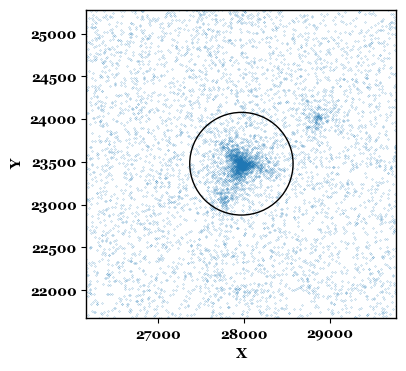



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/0327_0101440801_EMOS2_S002_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS2&&(PATTERN<=12)&&((X,Y) IN circle(27970.535,23478.742,600))&&(PI in [200.0:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='n

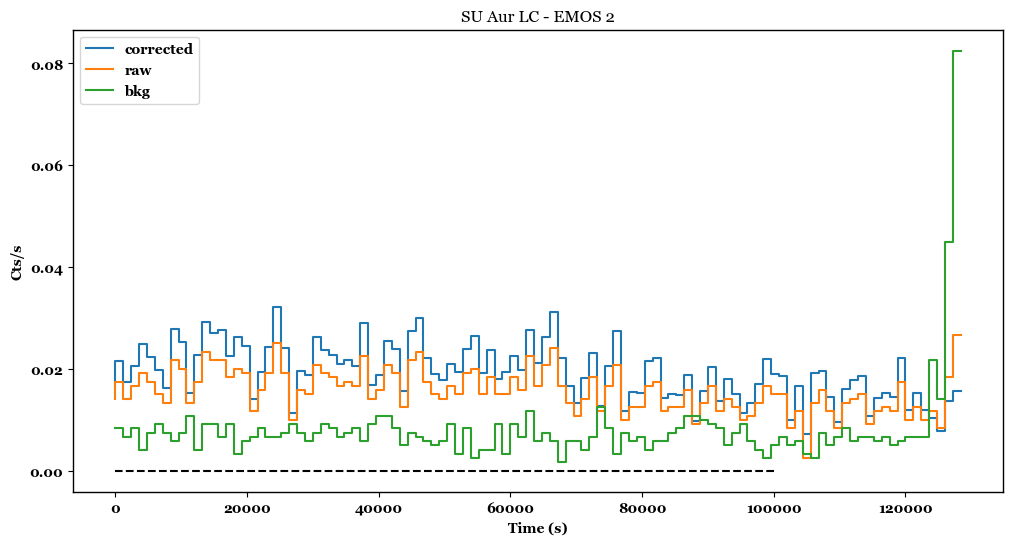

In [10]:
# SU Aur EMOS 2 Extraction

# Prepare
region_2     = (27970.535, 23478.742)
radius       = 600
bkg_2        = (27970.535, 27000.5)
bkg_radius   = 1400

q_flag       = "#XMMEA_EMOS2"
n_pattern    = 12          # Pattern selection
pi_min       = 200.        # Low energy range eV
pi_max       = 10000.      # High energy range eV
lc_bin       = 1200         # Lightcurve bin in secs
t_min        = 117423319.0
t_max        = 117552866.0

event_file   = '0327_0101440801_EMOS2_S002_ImagingEvts.ds'
source_file  = 'ABAur_0101440801_EMOS2_lc_1200.lc'
bkg_file     = 'ABAur_0101440801_EMOS2_bkg_lc_1200.lc' 
final_file   = 'ABAur_0101440801_EMOS2_final_lc_1200.lc'

# Extract
extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_2, radius, bkg_2, 
               bkg_radius, work_dir, event_file, source_file, bkg_file, final_file, t_min, t_max)

# Plot
plt.figure(figsize=(12,6))  # Size of figure
plot_LC(plt, final_file, label='corrected')          # Plot corrected light curve
plot_LC(plt, source_file, label='raw')       # Plot source region light curve
plot_LC(plt, bkg_file, label='bkg')       # Plot background region light curve
plt.hlines(0,100000, 0, 'k','--', zorder=0)
plt.title('SU Aur LC - EMOS 2')
plt.legend(loc='upper left')
# plt.savefig('SUAur_LC_EMOS2.pdf', bbox_inches='tight', pad_inches=0.1, format='pdf')
plt.show()

In [35]:
def rolling_median(y, window):
    median = np.zeros(len(y))
    for i in range(len(y)):
        median[i] = np.nanmedian(y[np.max([i-window, 0]) : np.min([i+window, len(y)])])
    return median

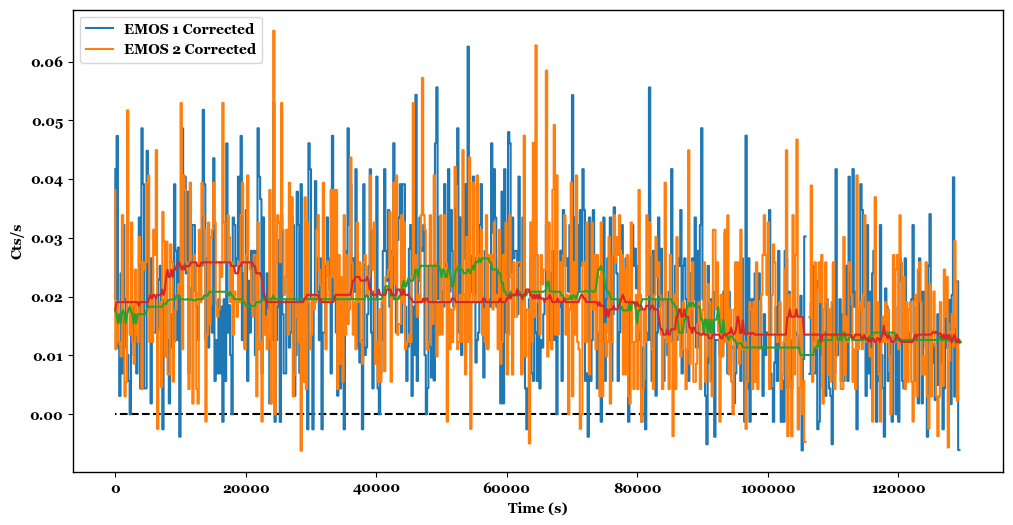

In [39]:
# Plot both SU Aur EMOS
plt.figure(figsize=(12,6))  # Size of figure
# plot_LC(plt, 'SUAur_0101440801_EMOS1_lc.lc', label='EMOS 1')
# plot_LC(plt, 'SUAur_0101440801_EMOS2_lc.lc', label='EMOS 2')
x1, y1 = plot_LC(plt, 'ABAur_0101440801_EMOS1_final_lc.lc', label='EMOS 1 Corrected')
x2, y2 = plot_LC(plt, 'ABAur_0101440801_EMOS2_final_lc.lc', label='EMOS 2 Corrected')
plt.plot(x1, rolling_median(y1, 30))
plt.plot(x2, rolling_median(y2, 30))
plt.hlines(0,100000, 0, 'k','--', zorder=0)
plt.title('')
plt.legend(loc='upper left')
# plt.savefig('SUAur_LC_EMOS.pdf', bbox_inches='tight', pad_inches=0.1, format='pdf')
plt.show()

Executing: 
elcbuild sets='ABAur_0101440801_EMOS1_final_lc_1200.lc ABAur_0101440801_EMOS1_final_lc_1200.lc' outset='/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_lc_1200.lc' 
elcbuild:- Executing (routine): elcbuild sets='ABAur_0101440801_EMOS1_final_lc_1200.lc ABAur_0101440801_EMOS1_final_lc_1200.lc' outset=/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_lc_1200.lc  -w 1 -V 4
elcbuild:- elcbuild (elcbuild-1.10)  [xmmsas_20230412_1735-21.0.0] started:  2024-09-18T15:16:00.000
elcbuild:- elcbuild (elcbuild-1.10)  [xmmsas_20230412_1735-21.0.0] ended:    2024-09-18T15:16:00.000
Filename: /Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_lc_1200.lc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   ()      
  1  RATE          1 BinTableHDU     76   109R x 5C   [2E, 2E, 2E, 2E, 2E]   


/Users/woodml/anaconda3/envs/Observing/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


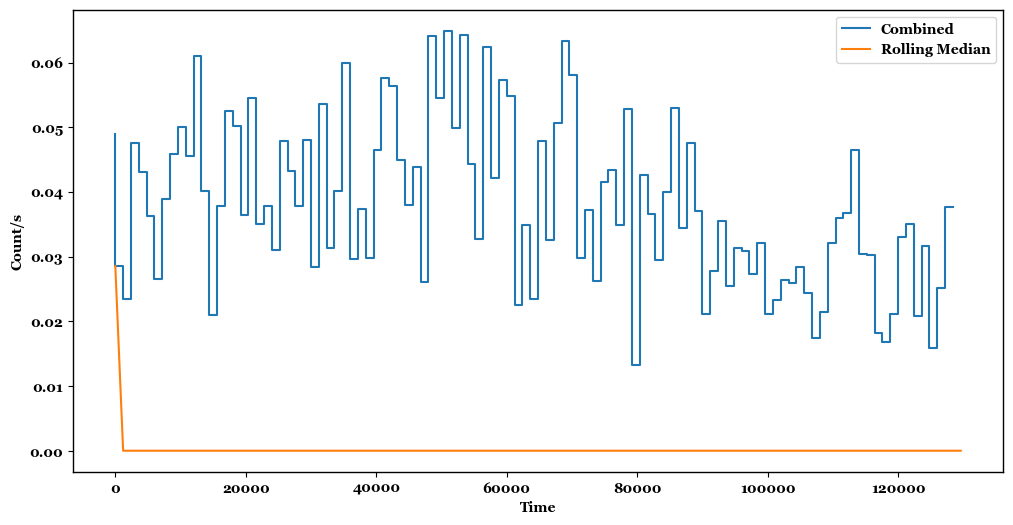

In [11]:
# Combine LCs
# - - - - - - - - - - - - - - - - 

combined_file = work_dir+'ABAur_0101440801_combined_lc_1200.lc'   # Name of the output corrected lightcurve

# SAS Command
cmd        = "elcbuild" # SAS task to be executed                  

# Arguments of SAS Command
inargs     = [f'sets=ABAur_0101440801_EMOS1_final_lc_1200.lc ABAur_0101440801_EMOS1_final_lc_1200.lc',
             f'outset={combined_file}']

w(cmd, inargs).run()

# Plot combined LC
hdul = fits.open(combined_file)
hdul.info()

lc = Table(hdul[1].data)

x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])-hdul[1].header['TSTART']

plt.figure(figsize=(12,6))
plt.step(x, np.sum(lc['RATE'], 1), label='Combined')
plt.plot(x, rolling_median(np.sum(lc['RATE'], 1), 3), label='Rolling Median')
plt.xlabel('Time')
plt.ylabel('Count/s')
plt.legend()
plt.title('')
plt.show()

# Soft and Hard LCs

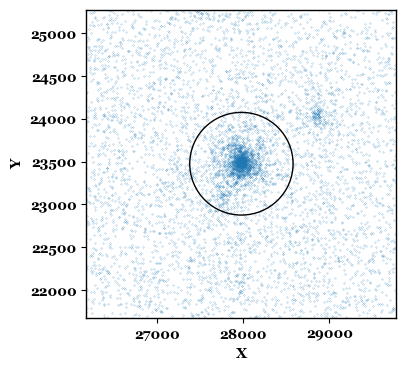



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/0327_0101440801_EMOS1_S001_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS1&&(PATTERN<=12)&&((X,Y) IN circle(27979.576,23475.568,600))&&(PI in [200.0:1500])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no' 

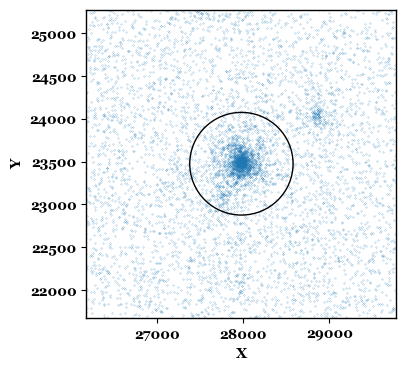



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/0327_0101440801_EMOS1_S001_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS1&&(PATTERN<=12)&&((X,Y) IN circle(27979.576,23475.568,600))&&(PI in [1500:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no

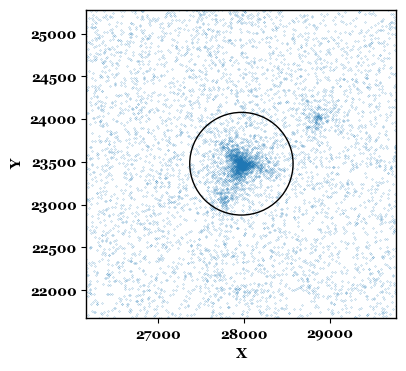



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/0327_0101440801_EMOS2_S002_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS2&&(PATTERN<=12)&&((X,Y) IN circle(27970.535,23478.742,600))&&(PI in [200.0:1500])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no' 

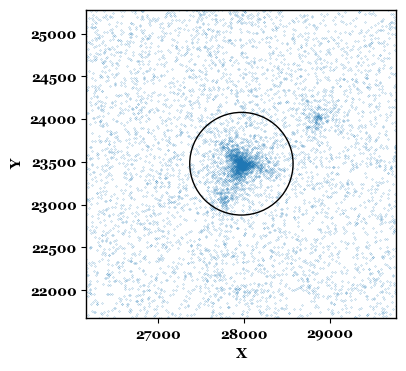



Extracting source LC




Time limits
Executing: 
evselect table='/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/0327_0101440801_EMOS2_S002_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS2&&(PATTERN<=12)&&((X,Y) IN circle(27970.535,23478.742,600))&&(PI in [1500:10000.0])' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialcenter='no

Making file temp_badcol.ds
epiclccorr::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX01:RAWX and temp_badcol.ds:BADPIX01:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
epiclccorr::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX02:RAWX and temp_badcol.ds:BADPIX02:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
epiclccorr::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX03:RAWX and temp_badcol.ds:BADPIX03:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
epiclccorr::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX04:RAWX and temp_badcol.ds:BADPIX04:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
epiclccorr::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX05:RAWX and temp_badcol.ds:BADPIX05:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
epiclccorr::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX06:RAWX and temp_badcol.ds:BADPIX06:RAWX is either non-existe

epiclccorr::arfgen:- Bad pixel & chip gap fraction: ~0 %
epiclccorr::arfgen:- Writing area data into dataset .. 
epiclccorr::arfgen:- Closing arfset on_ancillary.ds.
epiclccorr::arfgen:- arfgen (arfgen-1.104)  [xmmsas_20230412_1735-21.0.0] ended:    2024-01-08T16:18:41.000
epiclccorr:- arfgen (arfgen-1.104)  [xmmsas_20230412_1735-21.0.0] ended:    2024-01-08T16:18:41.000
epiclccorr:- Done.
epiclccorr:- Reading ancillary file... spectrum_SUAur_0101440801_EMOS2_hard.lc
epiclccorr:- Done.
epiclccorr:- Weighted Mean 1.158953980747950974
epiclccorr:- selected 1427 rows from the source input table.
epiclccorr:- Closing event file dataset
epiclccorr:- Extraction region lies in CCD number 1
epiclccorr:- Calculating the relative corrections for each CCD...
epiclccorr:- STDGTI01 extension found 
epiclccorr:- Processing GTI extension: STDGTI01 corresponding to CCD 1
epiclccorr:- STDGTI02 extension found 
epiclccorr:- STDGTI03 extension found 
epiclccorr:- STDGTI04 extension found 
epiclccorr:- ST

epiclccorr::evselect:- selected 1427 rows from the input table.
** epiclccorr::evselect: warning (NonStandardSpectrum), The standard PI channel range for MOS is 0-11999. Detector matrices can not be created for this spectrum and spectral fitting will not be possible.
epiclccorr::evselect:- evselect (evselect-3.71.2)  [xmmsas_20230412_1735-21.0.0] ended:    2024-01-08T16:18:42.000
epiclccorr:- evselect (evselect-3.71.2)  [xmmsas_20230412_1735-21.0.0] ended:    2024-01-08T16:18:42.000
epiclccorr:- Done.
epiclccorr:- Calculating arfgen...
epiclccorr:- Executing (invoked): arfgen spectrumset=spectrum_SUAur_0101440801_EMOS2_bkg_hard.lc rmfset=response.ds withrmfset=no arfset=bkg_ancillary.ds detmaptype=flat detmaparray=detmapfile.ds: detxoffset=1200 detyoffset=1200 withdetbounds=no detxbins=5 detybins=5 withdetbins=no psfenergy=2 filterdss=yes filteredset=filteredpixellist.ds withfilteredset=no sourcecoords=eqpos sourcex=0 sourcey=0 withsourcepos=no extendedsource=yes modeleffarea=yes model

epiclccorr::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.97325 fixeddec=30.585333 fixedposangle=83.562321 attitudelabel=fixed nominalra=73.97325 nominaldec=30.585333 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2024-01-08T16:18:46.000
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2024-01-08T16:18:46.000
epiclccorr::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.97325 fixeddec=30.585333 fixedposangle=83.562321 attitudelabel=fixed nominalra=73.97325 nominaldec=30.585333 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
epiclccorr::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2024-01-08T16:18:46.000
epiclccorr::arf

In [12]:
# SU Aur compare soft and hard LC
limit = 1500

# EMOS 1
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Soft
# - - - - - - - - - - -
region_1     = (27979.576, 23475.568)
radius       = 600
bkg_1        = (27979.576, 27000.5)
bkg_radius   = 1400

q_flag       = "#XMMEA_EMOS1" # Quality flag for EPIC pn
n_pattern    = 12             # Pattern selection
pi_min       = 200.           # Low energy range eV
pi_max       = limit          # High energy range eV
lc_bin       = 1200         # Lightcurve bin in secs
t_min        = 117423319.0
t_max        = 117552866.0

event_file  = '0327_0101440801_EMOS1_S001_ImagingEvts.ds'
source_file = 'ABAur_0101440801_EMOS1_soft_1200.lc'
bkg_file    = 'ABAur_0101440801_EMOS1_bkg_soft_1200.lc'
final_file  = 'ABAur_0101440801_EMOS1_final_soft_1200.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_1, radius, bkg_1, bkg_radius, 
           work_dir, event_file, source_file, bkg_file, final_file, t_min, t_max)

# Hard
# - - - - - - - - - - -
pi_min       = limit          # Low energy range eV
pi_max       = 10000.         # High energy range eV
# others same as above

source_file = 'ABAur_0101440801_EMOS1_hard.lc'
bkg_file    = 'ABAur_0101440801_EMOS1_bkg_hard_1200.lc'
final_file  = 'ABAur_0101440801_EMOS1_final_hard_1200.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_1, radius, bkg_1, bkg_radius, 
           work_dir, event_file, source_file, bkg_file, final_file, t_min, t_max)

# EMOS 2
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Soft
# - - - - - - - - - - -
region_2     = (27970.535, 23478.742)
radius       = 600
bkg_2        = (27970.535, 27000.5)
bkg_radius   = 1400

q_flag       = "#XMMEA_EMOS2" # Quality flag for EPIC mos
pi_min       = 200.           # Low energy range eV
pi_max       = limit          # High energy range eV
# others same as emos 1

event_file  = '0327_0101440801_EMOS2_S002_ImagingEvts.ds'
source_file = 'ABAur_0101440801_EMOS2_soft_1200.lc'
bkg_file    = 'ABAur_0101440801_EMOS2_bkg_soft_1200.lc'
final_file  = 'ABAur_0101440801_EMOS2_final_soft_1200.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_2, radius, bkg_2, bkg_radius, 
           work_dir, event_file, source_file, bkg_file, final_file, t_min, t_max)

# Hard
# - - - - - - - - - - -
pi_min       = limit          # Low energy range eV
pi_max       = 10000.         # High energy range eV
# others same as above

source_file = 'ABAur_0101440801_EMOS2_hard.lc'
bkg_file    = 'ABAur_0101440801_EMOS2_bkg_hard_1200.lc'
final_file  = 'ABAur_0101440801_EMOS2_final_hard_1200.lc'

extract_lc(q_flag, n_pattern, pi_min, pi_max, lc_bin, region_2, radius, bkg_2, bkg_radius, 
           work_dir, event_file, source_file, bkg_file, final_file, t_min, t_max)

In [13]:
# Combine soft and hard LCs for SU Aur from EMOS and PN
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Soft
# - - - - - - - - - - -
combined_file = work_dir + 'ABAur_0101440801_combined_soft_1200.lc'

# SAS Command
cmd        = "elcbuild" # SAS task to be executed                  

# Arguments of SAS Command
inargs     = [f'sets=ABAur_0101440801_EMOS1_final_soft_1200.lc ABAur_0101440801_EMOS2_final_soft_1200.lc', f'outset={combined_file}']

w(cmd, inargs).run()

# Hard 
# - - - - - - - - - - -
combined_file = work_dir+'ABAur_0101440801_combined_hard_1200.lc'

# SAS Command
cmd        = "elcbuild" # SAS task to be executed                  

# Arguments of SAS Command
inargs     = [f'sets=ABAur_0101440801_EMOS1_final_hard_1200.lc ABAur_0101440801_EMOS2_final_hard_1200.lc', f'outset={combined_file}']

w(cmd, inargs).run()

Executing: 
elcbuild sets='ABAur_0101440801_EMOS1_final_soft_1200.lc ABAur_0101440801_EMOS2_final_soft_1200.lc' outset='/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_soft_1200.lc' 
elcbuild:- Executing (routine): elcbuild sets='ABAur_0101440801_EMOS1_final_soft_1200.lc ABAur_0101440801_EMOS2_final_soft_1200.lc' outset=/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_soft_1200.lc  -w 1 -V 4
elcbuild:- elcbuild (elcbuild-1.10)  [xmmsas_20230412_1735-21.0.0] started:  2024-09-18T15:26:06.000
elcbuild:- elcbuild (elcbuild-1.10)  [xmmsas_20230412_1735-21.0.0] ended:    2024-09-18T15:26:06.000
Executing: 
elcbuild sets='ABAur_0101440801_EMOS1_final_hard_1200.lc ABAur_0101440801_EMOS2_final_hard_1200.lc' outset='/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_hard_1200.lc' 
elcbuild:- Executing (routine): elcbuild sets='ABAur_0101440801_EMOS1_final_hard_1200.lc ABAur_0101440801_EMOS2_final_hard_1200.

In [55]:
def rolling_median(y, window):
    median = np.zeros(len(y))
    for i in range(len(y)):
        median[i] = np.nanmedian(y[np.max([i-window, 0]) : np.min([i+window, len(y)])])
    return median

Filename: ABAur_0101440801_combined_soft.lc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   ()      
  1  RATE          1 BinTableHDU     76   432R x 5C   [2E, 2E, 2E, 2E, 2E]   
Filename: ABAur_0101440801_combined_hard.lc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      19   ()      
  1  RATE          1 BinTableHDU     76   432R x 5C   [2E, 2E, 2E, 2E, 2E]   


/var/folders/6r/b1vgrsvj6_11v9c7049hz5900000gq/T/ipykernel_42691/52362965.py:21: RuntimeWarning: invalid value encountered in divide
  ax[2].step(x_hard, (y_hard+y_soft)/(y_hard-y_soft))
/var/folders/6r/b1vgrsvj6_11v9c7049hz5900000gq/T/ipykernel_42691/52362965.py:22: RuntimeWarning: invalid value encountered in divide
  ax[2].step(x_hard, rolling_median((y_hard+y_soft)/(y_hard-y_soft), 15))


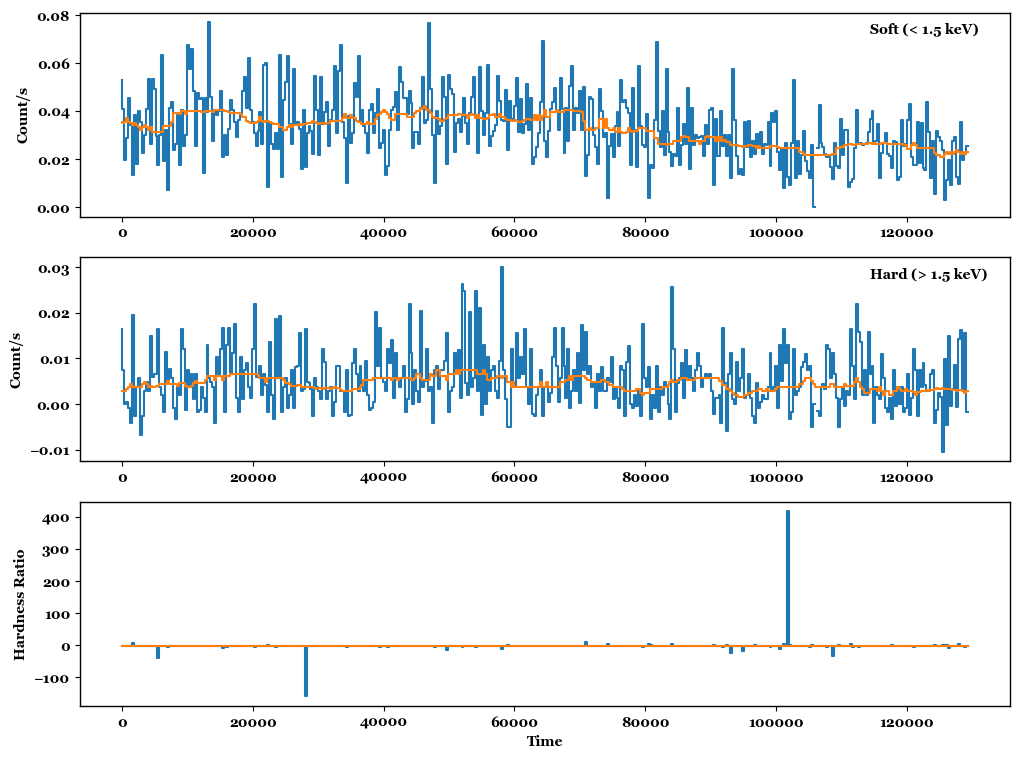

In [56]:
# Plot combined LC
hdul = fits.open('ABAur_0101440801_combined_soft.lc')
hdul.info()
lc_soft = Table(hdul[1].data)
x_soft = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])-hdul[1].header['TSTART']
y_soft = np.sum(lc_soft['RATE'], 1)

hdul = fits.open('ABAur_0101440801_combined_hard.lc')
hdul.info()
lc_hard = Table(hdul[1].data)
x_hard = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])-hdul[1].header['TSTART']
y_hard = np.sum(lc_hard['RATE'], 1)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12,9))
ax[0].step(x_soft, y_soft, label='Soft (< 1.5 keV)')
ax[0].step(x_soft, rolling_median(y_soft, 15))
ax[0].text(0.85, 0.9, 'Soft (< 1.5 keV)',  transform=ax[0].transAxes)
ax[1].step(x_hard, y_hard, label='Hard (> 1.5 keV)')
ax[1].step(x_hard, rolling_median(y_hard, 15))
ax[1].text(0.85, 0.9, 'Hard (> 1.5 keV)',  transform=ax[1].transAxes)
ax[2].step(x_hard, (y_hard+y_soft)/(y_hard-y_soft))
ax[2].step(x_hard, rolling_median((y_hard+y_soft)/(y_hard-y_soft), 15))
ax[2].set_xlabel('Time')
ax[0].set_ylabel('Count/s')
ax[1].set_ylabel('Count/s')
ax[2].set_ylabel('Hardness Ratio')
ax[0].set_title('')
plt.show()

# Spectra



Checking for Event Files...


File 0327_0101440801_EMOS1_S001_ImagingEvts.ds exists. 



Extracting source spectrum...


Executing: 
evselect table='0327_0101440801_EMOS1_S001_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS1&&(PATTERN<=12) && ((X,Y) IN circle(27979.576,23475.568,600))' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialc

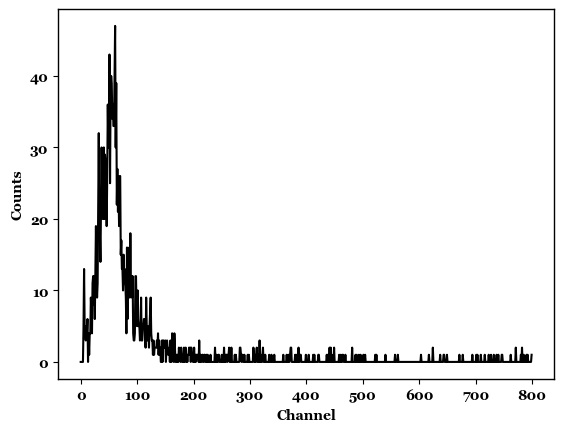

In [57]:
# SU Aur - EMOS 1

# Prepare
q_flag       = "#XMMEA_EMOS1" # Quality flag
n_pattern    = 12           # Pattern selection. Should be 12 for MOS detectors
region_1     = (27979.576, 23475.568)
radius       = 600
bkg_1        = (27979.576, 27000.5)
bkg_radius   = 1400
spec_min     = 0
spec_max     = 11999
bin_size     = 15

work_dir           = '/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/'
event_file         = '0327_0101440801_EMOS1_S001_ImagingEvts.ds'
source_file        = 'ABAur_0101440801_EMOS1_spec.fits'
bkg_file           = 'ABAur_0101440801_EMOS1_bkg_spec.fits'
response_file      = 'EPIC_MOS1.rmf'
ancillary_file     = 'EPIC_MOS1.anc'
final_file         = 'ABAur_0101440801_EMOS1_spec_final.fits'

# Extract
extract_spectrum(q_flag, n_pattern, bin_size, region_1, radius, bkg_1, bkg_radius, spec_min, spec_max,
                 work_dir, event_file, source_file, bkg_file, response_file, ancillary_file, final_file)

# Plot
plt.figure()
plot_spectrum(final_file, c='k')
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.title('')
plt.show()

In [58]:
# Su Aur - EMOS 2
# Final extraction

# Define some parameters for filtering the event file

q_flag       = "#XMMEA_EMOS2" # Quality flag
n_pattern    = 12           # Pattern selection. Should be 12 for MOS detectors
region_2     = (27970.535, 23478.742)
radius       = 600
bkg_2        = (27970.535, 27000.5)
bkg_radius   = 1400
spec_min     = 0
spec_max     = 11999
bin_size     = 15

work_dir           = '/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/'
event_file         = '0327_0101440801_EMOS2_S002_ImagingEvts.ds'
source_file        = 'ABAur_0101440801_EMOS2_spec.fits'
bkg_file           = 'ABAur_0101440801_EMOS2_bkg_spec.fits'
response_file      = 'EPIC_MOS2.rmf'
ancillary_file     = 'EPIC_MOS2.anc'
final_file         = 'ABAur_0101440801_EMOS2_spec_final.fits'

extract_spectrum(q_flag, n_pattern, bin_size, region_2, radius, bkg_2, bkg_radius,spec_min,
                 spec_max, work_dir, event_file, source_file,bkg_file,response_file,ancillary_file, final_file)



Checking for Event Files...


File 0327_0101440801_EMOS2_S002_ImagingEvts.ds exists. 



Extracting source spectrum...


Executing: 
evselect table='0327_0101440801_EMOS2_S002_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS2&&(PATTERN<=12) && ((X,Y) IN circle(27970.535,23478.742,600))' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatatype='no' imagedatatype='Real64' withcelestialc

arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.97325 fixeddec=30.585333 fixedposangle=83.562321 attitudelabel=fixed nominalra=73.97325 nominaldec=30.585333 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2024-01-08T17:16:06.000
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2024-01-08T17:16:06.000
arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.97325 fixeddec=30.585333 fixedposangle=83.562321 attitudelabel=fixed nominalra=73.97325 nominaldec=30.585333 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2024-01-08T17:16:06.000
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    20

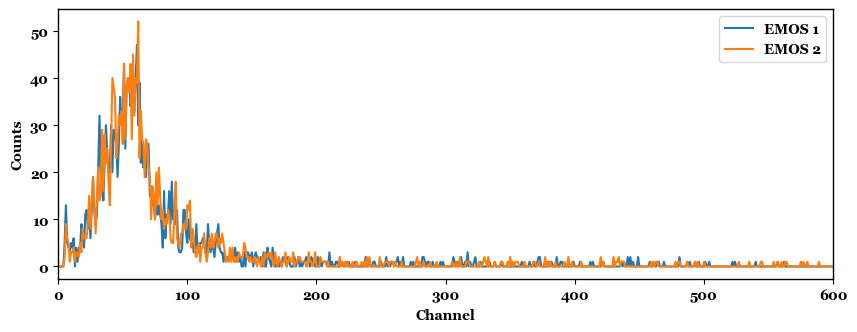

In [62]:
plt.figure(figsize=(10,3.5))
plot_spectrum('ABAur_0101440801_EMOS1_spec_final.fits', label='EMOS 1')
plot_spectrum('ABAur_0101440801_EMOS2_spec_final.fits', label='EMOS 2')
plt.legend(loc='upper right')
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.xlim(0,600)
plt.show()

# Flare Extraction

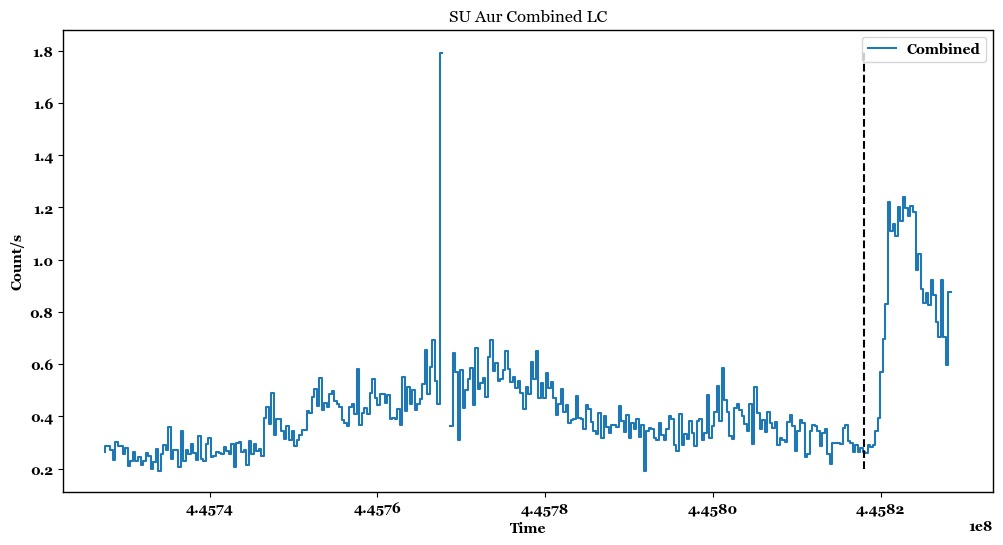

In [63]:
# Plot combined LC
hdul = fits.open(combined_file)
lc = Table(hdul[1].data)

x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])

plt.figure(figsize=(12,6))
plt.step(x, np.sum(lc['RATE'], 1), label='Combined')
plt.xlabel('Time')
plt.ylabel('Count/s')
plt.legend()
plt.title('SU Aur Combined LC')
plt.vlines(445818000, 0.2, 1.8, 'k', '--')
plt.show()

In [16]:
# SU Aur compare in and out of flare
limit = 445818000

# EMOS 1
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Before Flare
# - - - - - - - - - - -
SUAur_region_1  = (25260.645, 28188.236)
radius          = 800
bkg_1           = (25260.645, 25000.5)
bkg_radius      = 1800

q_flag          = "#XMMEA_EMOS1"
n_pattern       = 12
spec_min        = 0
spec_max        = 11999
bin_size        = 15
time_min        = 445727565.0
time_max        = limit

event_file         = '2232_0671960101_EMOS1_S001_ImagingEvts.ds'
source_file        = 'SUAur_EMOS1_spec_quiet.fits'
bkg_file           = 'SUAur_EMOS1_bkg_spec_quiet.fits'
response_file      = 'EPIC_MOS1.rmf'
ancillary_file     = 'EPIC_MOS1.anc'
final_file         = 'SUAur_EMOS1_final_spec_quiet.fits'

# Extract
extract_spectrum(q_flag, n_pattern, bin_size, SUAur_region_1, radius, bkg_1, bkg_radius, spec_min, spec_max,
                 work_dir, event_file, source_file, bkg_file, response_file, ancillary_file, final_file,
                 time_min=time_min, time_max=time_max)

# During Flare
# - - - - - - - - - - -
time_min     = limit
time_max     = 445828820.0
# others same as above

source_file = 'SUAur_EMOS1_spec_flare.fits'
bkg_file    = 'SUAur_EMOS1_bkg_spec_flare.fits'
final_file  = 'SUAur_EMOS1_final_spec_flare.fits'
# others same as above

extract_spectrum(q_flag, n_pattern, bin_size, SUAur_region_1, radius, bkg_1, bkg_radius, spec_min, spec_max,
                 work_dir, event_file, source_file, bkg_file, response_file, ancillary_file, final_file,
                 time_min=time_min, time_max=time_max)

# EMOS 2
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Before Flare
# - - - - - - - - - - -
region_2     = (25240.35, 28123.166)
radius       = 800.
bkg_2        = (25240.35, 25000.5) 
bkg_radius   = 1800.

q_flag          = "#XMMEA_EMOS2"
n_pattern       = 12
spec_min        = 0
spec_max        = 11999
bin_size        = 15
time_min        = 445727565.0
time_max        = limit

event_file         = '2232_0671960101_EMOS2_S002_ImagingEvts.ds'
source_file        = 'SUAur_EMOS2_spec_quiet.fits'
bkg_file           = 'SUAur_EMOS2_bkg_spec_quiet.fits'
response_file      = 'EPIC_MOS2.rmf'
ancillary_file     = 'EPIC_MOS2.anc'
final_file         = 'SUAur_EMOS2_final_spec_quiet.fits'

# Extract
extract_spectrum(q_flag, n_pattern, bin_size, SUAur_region_1, radius, bkg_1, bkg_radius, spec_min, spec_max,
                 work_dir, event_file, source_file, bkg_file, response_file, ancillary_file, final_file,
                 time_min=time_min, time_max=time_max)

# During Flare
# - - - - - - - - - - -
time_min     = limit
time_max     = 445828820.0
# others same as above

source_file = 'SUAur_EMOS2_spec_flare.fits'
bkg_file    = 'SUAur_EMOS2_bkg_spec_flare.fits'
final_file  = 'SUAur_EMOS2_final_spec_flare.fits'
# others same as above

extract_spectrum(q_flag, n_pattern, bin_size, SUAur_region_1, radius, bkg_1, bkg_radius, spec_min, spec_max,
                 work_dir, event_file, source_file, bkg_file, response_file, ancillary_file, final_file,
                 time_min=time_min, time_max=time_max)

# EPN
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Before Flare
# - - - - - - - - - - -

region_pn   = (25254.175, 28197.344)
radius      = 600.
bkg_pn      = (26455.5, 26965.5)
bkg_radius  = 800

q_flag          = "#XMMEA_EP"
n_pattern       = 4
spec_min        = 0
spec_max        = 20479
bin_size        = 1
time_min        = 445727565.0
time_max        = limit

event_file      = '2232_0671960101_EPN_S003_ImagingEvts.ds'
source_file     = 'SUAur_EPN_spec_quiet.fits'
bkg_file        = 'SUAur_EPN_bkg_spec_quiet.fits'
response_file   = 'EPIC_PN.rmf'
ancillary_file  = 'EPIC_PN.anc'
final_file      = 'SUAur_EPN_final_spec_quiet.fits'

# Extract
extract_spectrum(q_flag, n_pattern, bin_size, SUAur_region_1, radius, bkg_1, bkg_radius, spec_min, spec_max,
                 work_dir, event_file, source_file, bkg_file, response_file, ancillary_file, final_file,
                 time_min=time_min, time_max=time_max)
# During Flare
# - - - - - - - - - - -
time_min     = limit
time_max     = 445828820.0
# others same as above

source_file = 'SUAur_EPN_spec_flare.fits'
bkg_file    = 'SUAur_EPN_bkg_spec_flare.fits'
final_file  = 'SUAur_EPN_final_spec_flare.fits'
# others same as above

extract_spectrum(q_flag, n_pattern, bin_size, SUAur_region_1, radius, bkg_1, bkg_radius, spec_min, spec_max,
                 work_dir, event_file, source_file, bkg_file, response_file, ancillary_file, final_file,
                 time_min=time_min, time_max=time_max)



Checking for Event Files...


File 2232_0671960101_EMOS1_S001_ImagingEvts.ds exists. 



Extracting source spectrum...


Executing: 
evselect table='2232_0671960101_EMOS1_S001_ImagingEvts.ds' keepfilteroutput='no' withfilteredset='no' filteredset='filtered.fits' destruct='yes' flagcolumn='EVFLAG' flagbit='-1' filtertype='expression' dssblock='' expression='#XMMEA_EMOS1&&(PATTERN<=12) && ((X,Y) IN circle(25260.645,28188.236,800)) && (445727565.0 < TIME) && (TIME < 445818000)' writedss='yes' cleandss='no' updateexposure='yes' filterexposure='yes' blockstocopy='' attributestocopy='' energycolumn='PI' withzcolumn='no' zcolumn='WEIGHT' withzerrorcolumn='no' zerrorcolumn='EWEIGHT' ignorelegallimits='no' withimageset='no' imageset='image.fits' xcolumn='RAWX' ycolumn='RAWY' imagebinning='imageSize' ximagebinsize='1' yimagebinsize='1' squarepixels='no' ximagesize='600' yimagesize='600' withxranges='no' ximagemin='1' ximagemax='640' withyranges='no' yimagemin='1' yimagemax='640' withimagedatat

Making file temp_badcol.ds
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX01:RAWX and temp_badcol.ds:BADPIX01:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX02:RAWX and temp_badcol.ds:BADPIX02:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX03:RAWX and temp_badcol.ds:BADPIX03:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX04:RAWX and temp_badcol.ds:BADPIX04:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX05:RAWX and temp_badcol.ds:BADPIX05:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX07:RAWX and temp_badcol.ds:BADPIX07:RAWX is either non-existent or 

backscale::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-18T19:10:31.000
Making file temp_badcol.ds
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX01:RAWX and temp_badcol.ds:BADPIX01:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX02:RAWX and temp_badcol.ds:BADPIX02:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX03:RAWX and temp_badcol.ds:BADPIX03:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX04:RAWX and temp_badcol.ds:BADPIX04:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS info for the columns temp_badcol.ds:BADPIX05:RAWX and temp_badcol.ds:BADPIX05:RAWX is either non-existent or incomplete. Assuming a 1:1 mapping
backscale::arfgen:- WCS i

rmfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
rmfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:10:40.000
rmfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-18T19:10:40.000
rmfgen:-  RmfDataServer created ok.
rmfgen:- Opening data set ...
rmfgen:- Opened data set.
rmfgen:- Adding MATRIX table. There will be 2400 rows in table 
rmfgen:- Initialising table iterator ..
rmfgen:- Populating table ..
rmfgen:- No groups found for row 0 Will fill F_CHAN, N_CHAN and MATRIX columns with zeroes 
rmfgen:- No groups found for row 1 Will fill F_CHAN, N_CHAN and MATRIX columns with zeroes 
rmfgen:- No groups found for row 2 Will fill F_CHAN, N_CHAN and MATRIX column

arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:11:06.000
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-18T19:11:06.000
arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:11:06.000
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:

...

evselect:- selected 1976 rows from the input table.
evselect:- evselect (evselect-3.71.2)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-18T19:15:24.000


Backscaling source spectrum...


Executing: 
backscale spectrumset='/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_spec_flare.fits' badpixlocation='2232_0671960101_EPN_S003_ImagingEvts.ds' withbadpixcorr='yes' useodfatt='no' ignoreoutoffov='yes' withbadpixres='no' badpixelresolution='2' 
backscale:- Executing (routine): backscale spectrumset=/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_spec_flare.fits badpixlocation=2232_0671960101_EPN_S003_ImagingEvts.ds withbadpixcorr=yes useodfatt=no ignoreoutoffov=yes badpixelresolution=2 withbadpixres=no  -w 1 -V 4
backscale:- backscale (backscale-1.6)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:15:25.000
backscale:- Executing (routine): arfgen spectrumset=/Users/woodml/Observing/XMM-Newton/0671960101/SUAur_EPN_spec_flare.fits rmfset=response.ds withrmfset=no arf

backscale::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
backscale::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:15:26.000
backscale::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-18T19:15:26.000
backscale::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
backscale::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:15:26.000
backscale::arf

backscale::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-18T19:15:30.000
backscale::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
backscale::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:15:30.000
backscale::arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-18T19:15:30.000
backscale::arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
backscale::arf

rmfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
rmfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:15:34.000
rmfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-18T19:15:34.000
** rmfgen: warning (invalidCCFChannels), Can't rebin channel boundaries from the CCF - using regular bins 
rmfgen:-  RmfDataServer created ok.
rmfgen:- Opening data set ...
rmfgen:- Opened data set.
rmfgen:- Adding MATRIX table. There will be 2067 rows in table 
rmfgen:- Initialising table iterator ..
rmfgen:- Populating table ..
rmfgen:- Adding EBOUNDS extension ... 
rmfgen:-  Cleanup ... 
rmfgen:-  Closing data set ... 
rmfgen:-  Closed data set.
rmfgen:-  Cleanup complete. 
rmfg

arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:16:18.000
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:    2023-12-18T19:16:18.000
arfgen:- Executing (routine): attcalc eventset=rawpixellist.ds:EVENTS fixedra=73.986917 fixeddec=30.535611 fixedposangle=266.395294 attitudelabel=fixed nominalra=73.986917 nominaldec=30.535611 setpnttouser=no refpointlabel=user atthkset=atthk.dat withatthkset=no withmedianpnt=yes calctlmax=no imagesize=0.36  -w 1 -V 4
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] started:  2023-12-18T19:16:18.000
arfgen:- attcalc (attcalc-4.39)  [xmmsas_20230412_1735-21.0.0] ended:

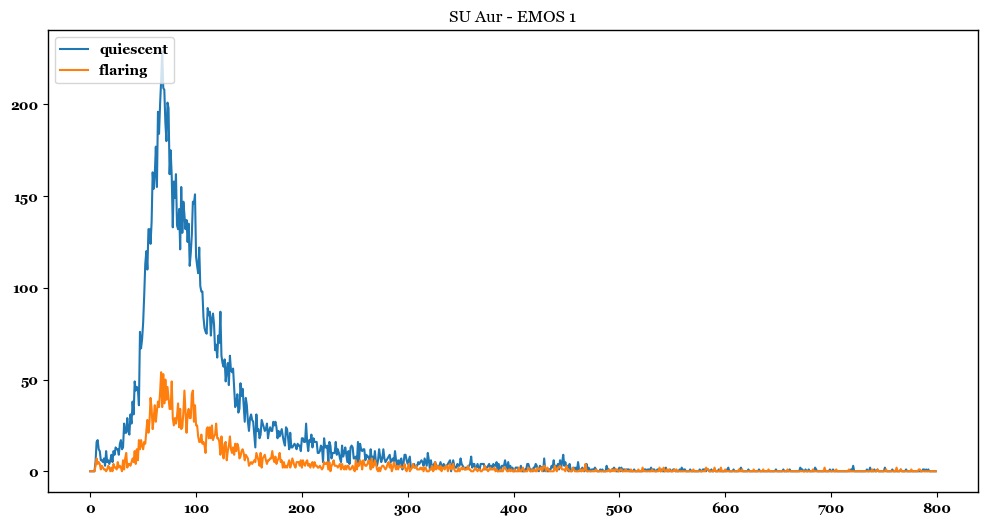

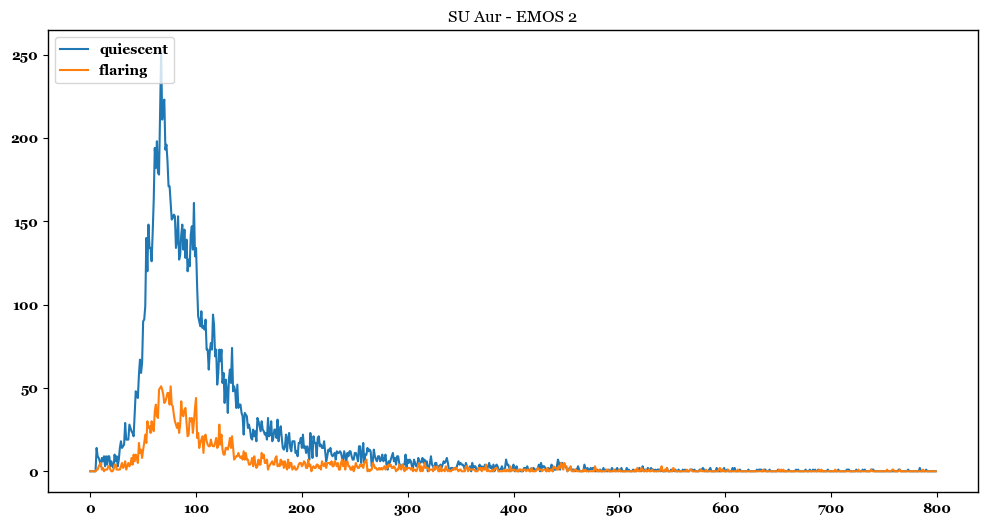

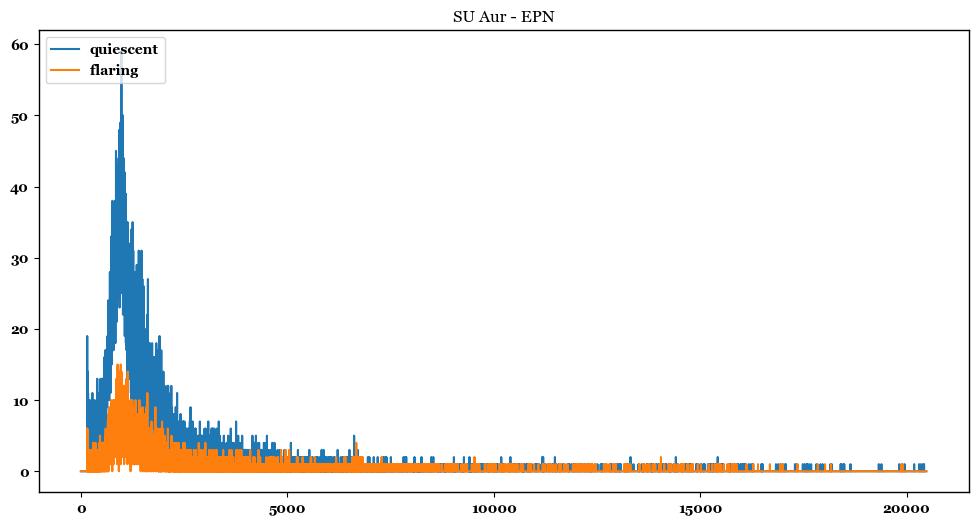

In [13]:
# PLOT
plt.figure(figsize=(12,6))  # Size of figure
plot_spectrum('SUAur_EMOS1_final_spec_quiet.fits', label='quiescent')
plot_spectrum('SUAur_EMOS1_final_spec_flare.fits', label='flaring')
plt.title('SU Aur - EMOS 1')
plt.legend(loc='upper left')
plt.show()

# PLOT
plt.figure(figsize=(12,6))  # Size of figure
plot_spectrum('SUAur_EMOS2_final_spec_quiet.fits', label='quiescent')
plot_spectrum('SUAur_EMOS2_final_spec_flare.fits', label='flaring')
plt.title('SU Aur - EMOS 2')
plt.legend(loc='upper left')
plt.show()

# PLOT
plt.figure(figsize=(12,6))  # Size of figure
plot_spectrum('SUAur_EPN_final_spec_quiet.fits', label='quiescent')
plot_spectrum('SUAur_EPN_final_spec_flare.fits', label='flaring')
plt.title('SU Aur - EPN')
plt.legend(loc='upper left')
plt.show()

In [93]:
quiet = fits.open('SUAur_EMOS1_final_spec_quiet.fits')[1]
flare = fits.open('SUAur_EMOS1_final_spec_flare.fits')[1]

print(quiet.header)

print(Table(quiet.data))
print(Table(flare.data))

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional binary table                     NAXIS1  =                   10 / width of table in bytes                        NAXIS2  =                  800 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group (required keyword)              TFIELDS =                    4 / number of fields in each row                   TTYPE1  = 'CHANNEL '           / The name of this column                        TFORM1  = 'I       '           / data format of field: 2-byte INTEGER           TTYPE2  = 'COUNTS  '           / The name of this column                        TFORM2  = 'J       '           / data format of field: 4-byte INTEGER           TUNIT2  = 'count   '           / physica

In [6]:
MJD = [12,21,23,430,230,1203]
n = 50000

In [10]:
%time RV = np.zeros((len(MJD), n))
print(len(RV), len(RV[0]))

CPU times: user 2.01 ms, sys: 2.37 ms, total: 4.38 ms
Wall time: 2.4 ms
6 50000


In [11]:
%time RV = [[0.0 for _ in range(len(MJD))] for _ in range(n)]
print(len(RV), len(RV[0]))

CPU times: user 99.2 ms, sys: 7.24 ms, total: 106 ms
Wall time: 105 ms
50000 6


# RGS Spectra